# Métropole du Grand Nancy

# 0. Configuration

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import ee
import geemap
import osmnx as ox
from rasterio import features
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# tools for spatial operations
sys.path.insert(1, '../../Hugo/a_b_c_functions/spatial_analysis/')
from utils_vector import gdf_to_bbox, unify_data
from utils_proj import get_utm_epsg
sys.path.insert(1, '../../Hugo/a_b_c_functions/gee_with_python/')
from utils_gee import prepare_ds_xarray_ee
from utils_raster import compute_area_percentage, polygon_to_raster, raster_to_polygon
sys.path.insert(1, '../../Hugo/a_b_c_functions/OSM/')
from get_boundary import get_boundary 

# personal modules
sys.path.insert(1, '../../marion/corridor_project/modules/')
import landcover as lc
import connectivity as conn
import routing as rout
sys.path.insert(1, '../../marion/corridor_project/config/')
import species_params

# Authentification GEE
service_account = 'gee-141@gee161025.iam.gserviceaccount.com'
credentials_path = '../../marion/credentials/gee161025-533af22f806b.json'
credentials = ee.ServiceAccountCredentials(service_account, credentials_path)
ee.Initialize(credentials)

# case study def
CITY = "Nancy"
GUILD_KEY = "mid_walker"
specie = species_params.SPECIES_CONFIG[GUILD_KEY]
OUTPUT_DIR = f"/home/jovyan/work/team/marion/corridor_project/results_connectivity/{CITY}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paramètres AOI
url_aoi = "https://geo.api.gouv.fr/epcis?nom=Grand%20Nancy&format=geojson&geometry=contour"
aoi_raw = gpd.read_file(url_aoi)
dept = "D054"
utm_epsg = f"EPSG:{get_utm_epsg(gdf=aoi_raw)}"
aoi_utm = aoi_raw.to_crs(utm_epsg)
aoi_ee = geemap.gdf_to_ee(gdf_to_bbox(aoi_utm))

Skipping field codesDepartements: unsupported OGR type: 5
Skipping field codesRegions: unsupported OGR type: 5
/tmp/ipykernel_554519/226246478.py:49: DeprecationWarning: This function is deprecated for geodataframes. Use `gdf.estimate_utm_crs()` instead.
  utm_epsg = f"EPSG:{get_utm_epsg(gdf=aoi_raw)}"


In [5]:
import importlib
from modules import landcover as lc
from modules import connectivity as conn
from modules import routing as rout
import species_params
importlib.reload(lc)
importlib.reload(conn)
importlib.reload(rout)
importlib.reload(species_params)

<module 'species_params' from '/home/jovyan/work/team/marion/corridor_project/../../marion/corridor_project/config/species_params.py'>

# 1. Landcover

In [6]:
da_lc = lc.get_city_landcover(aoi_ee=aoi_ee, aoi_raw=aoi_raw)

# Check
print(f"Valeurs : {np.unique(da_lc.values)}")

/home/jovyan/.local/lib/python3.11/site-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


Valeurs : [10. 30. 40. 50. 51. 60. 80. 90. nan]


# 2. Habitat Morphology - MSPA

In [7]:
# 1. Définition des habitats pour le 'mid_walker'
habitat_codes = specie['habitat_codes']
binary_wc = conn.get_binary_habitat(da_lc, habitat_codes)

# 2. Calcul des catégories morphologiques
# edge_width_pixels=1 signifie qu'on retire 10m sur tout le contour
core_arr, islet_arr = conn.fast_mspa(binary_wc.values, edge_width_pixels=1)

# 3. Vectorisation et filtrage par surface
# On récupère la transformation spatiale du raster original
transform = da_lc.rio.transform()

# Réservoirs (Cores) > 1 hectare
gdf_cores = conn.vectoriser_et_filtrer(core_arr, transform, utm_epsg, min_area_ha=1.0, label_name="Core")
# Stepping Stones (Islets) > 0.1 hectare
gdf_islets = conn.vectoriser_et_filtrer(islet_arr, transform, utm_epsg, min_area_ha=0.1, label_name="Islet")

print(f"✓ {len(gdf_cores)} Réservoirs et {len(gdf_islets)} Stepping Stones identifiés.")

✓ 296 Réservoirs et 590 Stepping Stones identifiés.


# 3. Graph Connectivity Analysis

Analyse de connectivité probabiliste (indice PC) et structurelle (Centralité).

In [8]:
# 1. Préparation des nœuds
df_nodes = conn.prepare_graph_nodes(gdf_cores, gdf_islets)

# 2. Construction du Graphe (utilise d0 et k de ton espèce)
G = conn.build_connectivity_graph_knn(df_nodes, specie)

# 3. Calcul de l'indice PC (Perméabilité globale)
# On calcule la surface totale de l'AOI en km2
total_area_km2 = aoi_utm.area.sum() / 1e6
pc_value = conn.calculate_pc_index(G, total_area_km2)

# 4. Extraction des corridors prioritaires
gdf_corridors = conn.get_priority_corridors(G, crs=utm_epsg, percentile=10)

print(f"Indice PC pour {CITY} : {pc_value:.6f}")
print(f"{len(gdf_corridors)} corridors prioritaires identifiés.")

Indice PC pour Nancy : 0.014492
423 corridors prioritaires identifiés.


# 4. Least Cost Path

In [9]:
# 1. Calcul des vrais tracés (LCP)
gdf_lcp = rout.compute_lcp_network(gdf_corridors, df_nodes, da_lc, specie['friction'])

# 2. Calcul de la tortuosité
gdf_lcp['tortuosity'] = gdf_lcp['real_dist'] / gdf_lcp['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp['tortuosity'].mean():.3f}")

Tracing LCPs: 100%|██████████| 423/423 [01:04<00:00,  6.58it/s]

Average Tortuosity for Nancy: 2.503


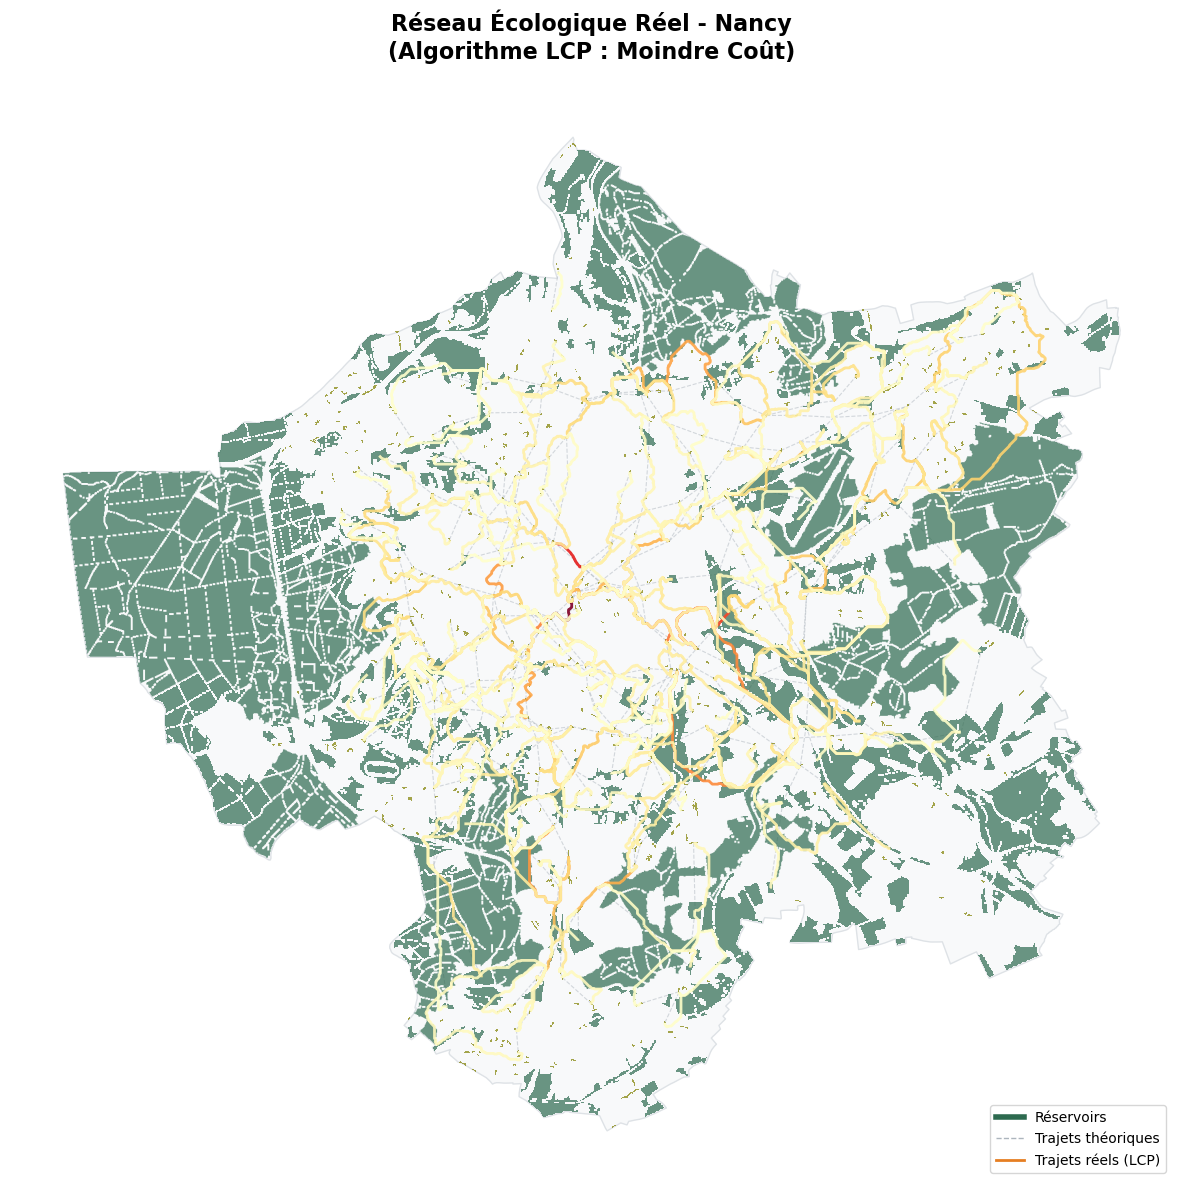

In [10]:
fig, ax = plt.subplots(figsize=(14, 12))
aoi_utm.plot(ax=ax, color='#f8f9fa', edgecolor='#dee2e6', zorder=1)
gdf_corridors.plot(ax=ax, color='#adb5bd', linestyle='--', linewidth=0.8, 
                   alpha=0.5, label='Dist. Théorique (Euclidienne)', zorder=2)

# Les Vrais Chemins (LCP) en orange/rouge
# Plus le trait est épais, plus le corridor est "important" (Centralité)
gdf_lcp.plot(ax=ax, column='importance_score', cmap='YlOrRd', linewidth=2, 
             alpha=0.9, label='Chemins de moindre coût (LCP)', zorder=4)

gdf_cores.plot(ax=ax, color='#2d6a4f', edgecolor='none', alpha=0.7, 
               label='Réservoirs d\'habitat', zorder=3)
gdf_islets.plot(ax=ax, color='olive', edgecolor='none', alpha=0.7, 
               label='Stepping Stones', zorder=3)

plt.title(f"Réseau Écologique Réel - {CITY}\n(Algorithme LCP : Moindre Coût)", 
          fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='#2d6a4f', lw=4),
                Line2D([0], [0], color='#adb5bd', lw=1, linestyle='--'),
                Line2D([0], [0], color='#e67e22', lw=2)]
ax.legend(custom_lines, ['Réservoirs', 'Trajets théoriques', 'Trajets réels (LCP)'], 
          loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

# 5. Circuit Theory